# Week 7.2 - Sparse-sensor state estimation of a cylinder wake
<!-- MIE690A article-aligned validation v4 -->

Can present noisy measurements correct a reduced forecast without using future
observations? We compare a causal POD-space Kalman filter with matched open-loop,
persistence and sensor-only baselines on existing FlowMLLab LBM fields.

Prerequisites: Weeks 5 and 7; allow 75-90 minutes; CPU only. This is a previously
inspected Re110 trajectory with synthetic measurement noise, not new CFD, new-Re
generalization or grid-independent truth. Lecture:
`lectures/week07_2_cylinder_state_estimation.pdf`.
<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week07_2/W7_2_Cylinder_Wake_State_Estimation.ipynb)


In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week07_2"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

from pathlib import Path
import hashlib, json, sys, tempfile
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'flowmllab/state_estimation.py').is_file())
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT/'qa'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from flowmllab.modal_experiments import load_cases
from flowmllab.state_estimation import *
from run_week72_state_estimation import PLAN, experiment, make_figures
tracked = [p for folder in ('data/modal_labs','results/week07_2_state_estimation') for p in (ROOT/folder).rglob('*') if p.is_file()]
before = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in tracked}
cases = load_cases(ROOT/'data/modal_labs')
display(PLAN)

{'case': 110,
 'field': 'v',
 'train': [0, 160],
 'validation': [160, 210],
 'test': [210, 281],
 'ranks': [4, 6, 8],
 'sensor_counts': [8, 16, 32],
 'noise_fraction_of_training_rms': 0.1,
 'seeds': [31, 32, 33, 34, 35],
 'process_covariance_scales': [1, 10, 100, 1000],
 'selection': 'minimum mean validation Kalman relative L2; tie favors fewer sensors, lower rank, then lower inflation'}

## 1. Information contracts before equations

Write down what each method may observe after training:

- **Open-loop:** the last training state only.
- **Causal filter:** measurements through the current time.
- **Sensor-only:** the same current measurements, but no temporal model.
- **Smoother:** current and future measurements; defined here but not evaluated.

Comparing filtering with sensor-only is essential: otherwise improvement over
open-loop could be caused merely by receiving new data.

## 2. Reduced state and observation models

With row-vector modal coefficients,
$q_k=\bar q+\Phi a_k$, $a_{k+1}=a_kA+w_k$, and
$y_k=\bar q_s+Ha_k+v_k$. Fit POD, $A$, residual covariance and sensor positions
on training only. The implementation uses QR-seeded D-optimal oversampling.

Derive the predict/update equations. Explain why explicitly forming the
innovation-covariance inverse is unnecessary, and why Joseph's covariance form
is numerically safer.

The control uses exactly two full cycles (105 training frames); a partial-cycle mean biases a homogeneous DMD fit. The tight 2% gate tests the intended linear system, not that bias.

In [2]:
# Exact low-rank causal control before the CFD experiment.
rng = np.random.default_rng(4)
phi, _ = np.linalg.qr(rng.normal(size=(24,2)))
z = np.array([[np.cos(4*np.pi*k/105), np.sin(4*np.pi*k/105)] for k in range(145)])
control = z @ phi.T
model0 = fit_reduced_kalman(control[:105], 2, 5, .01)
y0 = control[105:,model0.sensor_indices] + rng.normal(0,.01,(40,5))
states0, cov0, _ = kalman_filter(model0,y0)
error0 = np.linalg.norm(reconstruct_states(model0,states0)-control[105:])/np.linalg.norm(control[105:])
assert error0 < .02 and np.all(np.linalg.eigvalsh(cov0) >= -1e-12)
full = kalman_filter(model0,y0)[0]
prefix = kalman_filter(model0,y0[:5])[0]
np.testing.assert_allclose(full[:5],prefix)
print('Known-system relative error:',error0)
print('PASS: covariance PSD and prefix invariance (causality).')

Known-system relative error: 0.004739198203501766
PASS: covariance PSD and prefix invariance (causality).


In [3]:
# One explicit Kalman update, using column-state covariance conventions.
H=model0.modes[model0.sensor_indices]
x=model0.initial_mean @ model0.transition
P=model0.transition.T @ model0.initial_covariance @ model0.transition + model0.process_covariance
innovation=y0[0]-model0.mean[model0.sensor_indices]-H@x
S=H@P@H.T+model0.observation_covariance
K=np.linalg.solve(S,H@P).T
x=x+K@innovation
I_KH=np.eye(len(x))-K@H
P=I_KH@P@I_KH.T+K@model0.observation_covariance@K.T  # Joseph form
np.testing.assert_allclose(x,states0[0],atol=1e-12)
np.testing.assert_allclose(P,cov0[0],atol=1e-12)

## 3. Freeze selection before the test

Training frames are `[0,160)`, validation `[160,210)`, test `[210,281)`.
Validation compares ranks 4/6/8, sensor counts 8/16/32, and process-covariance
scales 1/10/100/1000 using five noise seeds. Noise is 10% of training-field RMS.
Five different seeds are reserved for final evaluation. Test truth selects nothing.

Inflation 1000 lies at the upper edge of the searched grid. It is the best **tested** value, not evidence of a global optimum. Extend the validation grid before making that claim. QR sensor placement follows [Manohar et al.](https://arxiv.org/abs/1701.07569).

In [4]:
scratch = Path(tempfile.mkdtemp(prefix='flowmllab-week72-'))
result, model, examples = experiment(cases)
make_figures(scratch,cases,result,model,examples)
display(pd.DataFrame(result['candidates']).sort_values('validation_relative_l2_mean').head(12))
print('Selected:',result['selected'])
print('Fresh figures written to a temporary folder:', scratch.name)

,rank,sensor_count,process_covariance_scale,validation_relative_l2_mean,validation_relative_l2_std
35,8,32,1000,0.021900,0.000946
31,8,16,1000,0.024244,0.000596
34,8,32,100,0.028857,0.000924
27,8,8,1000,0.029056,0.002302
30,8,16,100,0.030195,0.000676
29,8,16,10,0.032527,0.000809
28,8,16,1,0.032838,0.000831
33,8,32,10,0.032917,0.000906
32,8,32,1,0.033579,0.000915
26,8,8,100,0.033964,0.002240


Selected: {'rank': 8, 'sensor_count': 32, 'process_covariance_scale': 1000, 'validation_relative_l2_mean': 0.02189995622532397, 'validation_relative_l2_std': 0.000946202058350594}
Fresh figures written to a temporary folder: flowmllab-week72-px7av6o4


## 4. Compare matched baselines

Open-loop DMD receives no future measurements. Persistence repeats frame 159.
Sensor-only independently solves the POD observation least-squares problem at
each time and receives exactly the same noisy measurements as the Kalman filter.

Report mean and sample SD across the five measurement-noise seeds. These seeds
are not independent CFD realizations and do not support population confidence
intervals.

,method,test_relative_L2_mean_percent,sample_SD_percent
0,kalman,2.179371,0.065881
3,sensor_only,3.163281,0.063800
1,open_loop,4.359355,0.000000
2,persistence,131.813439,0.000000


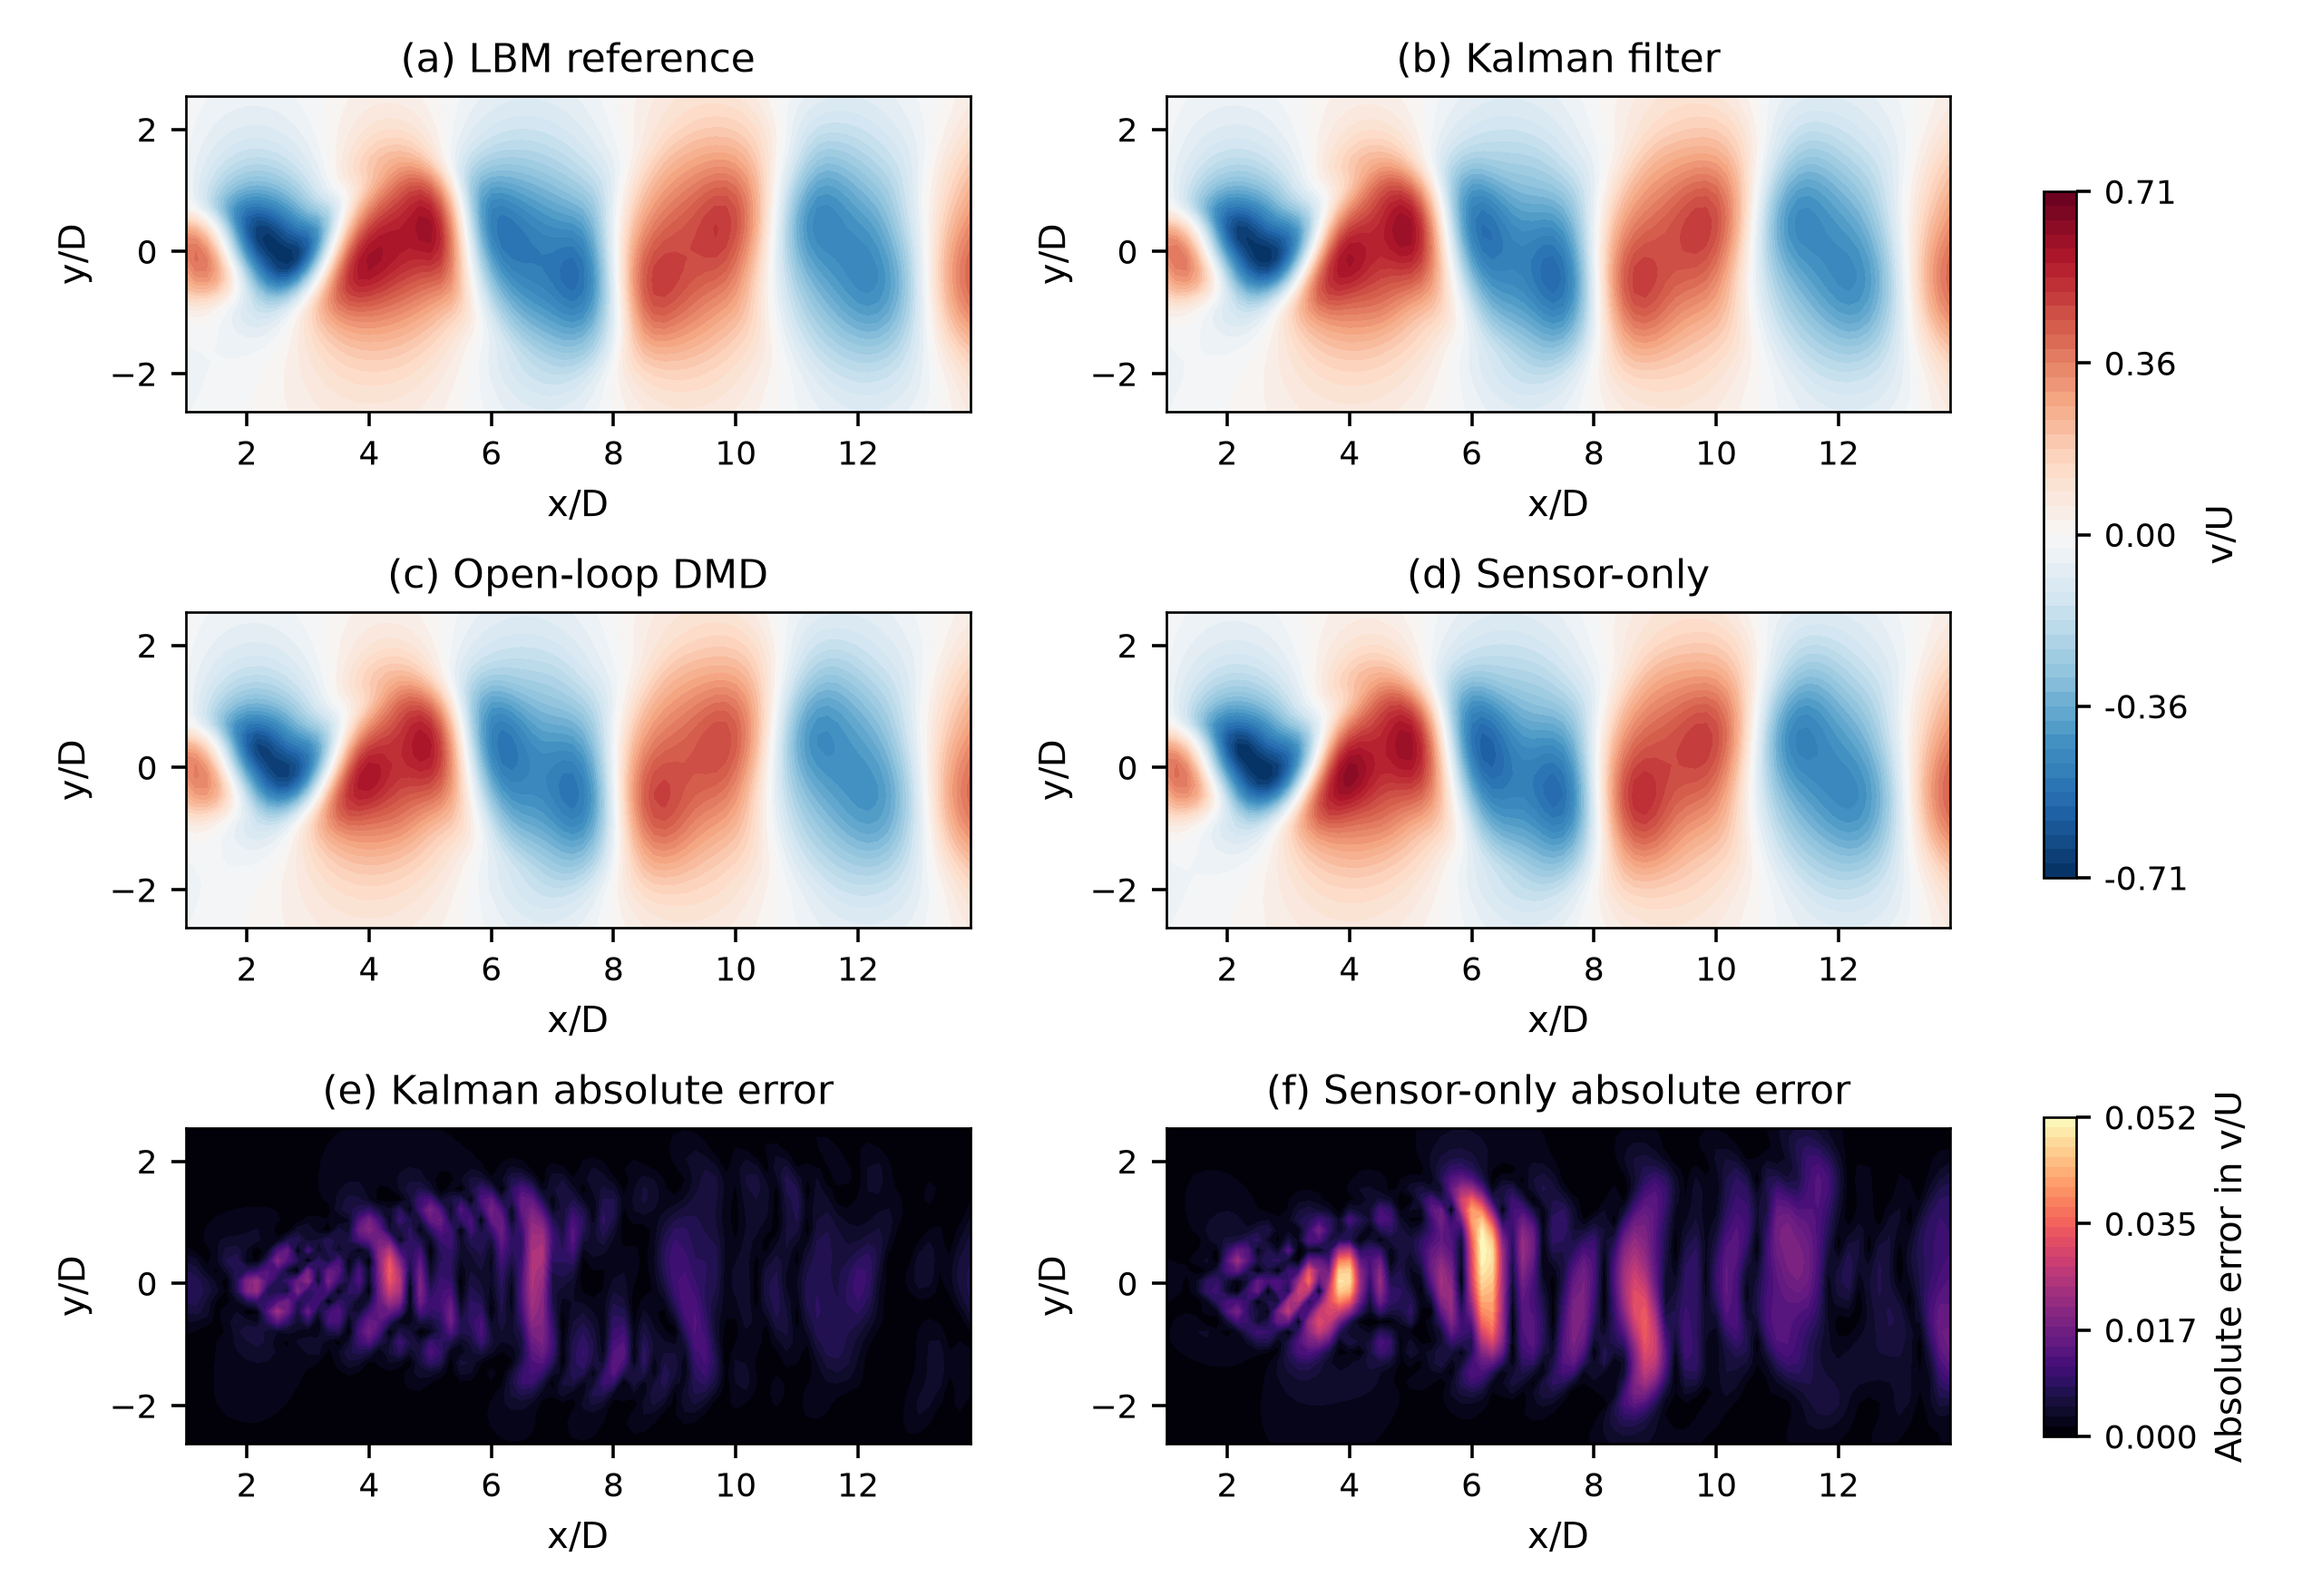

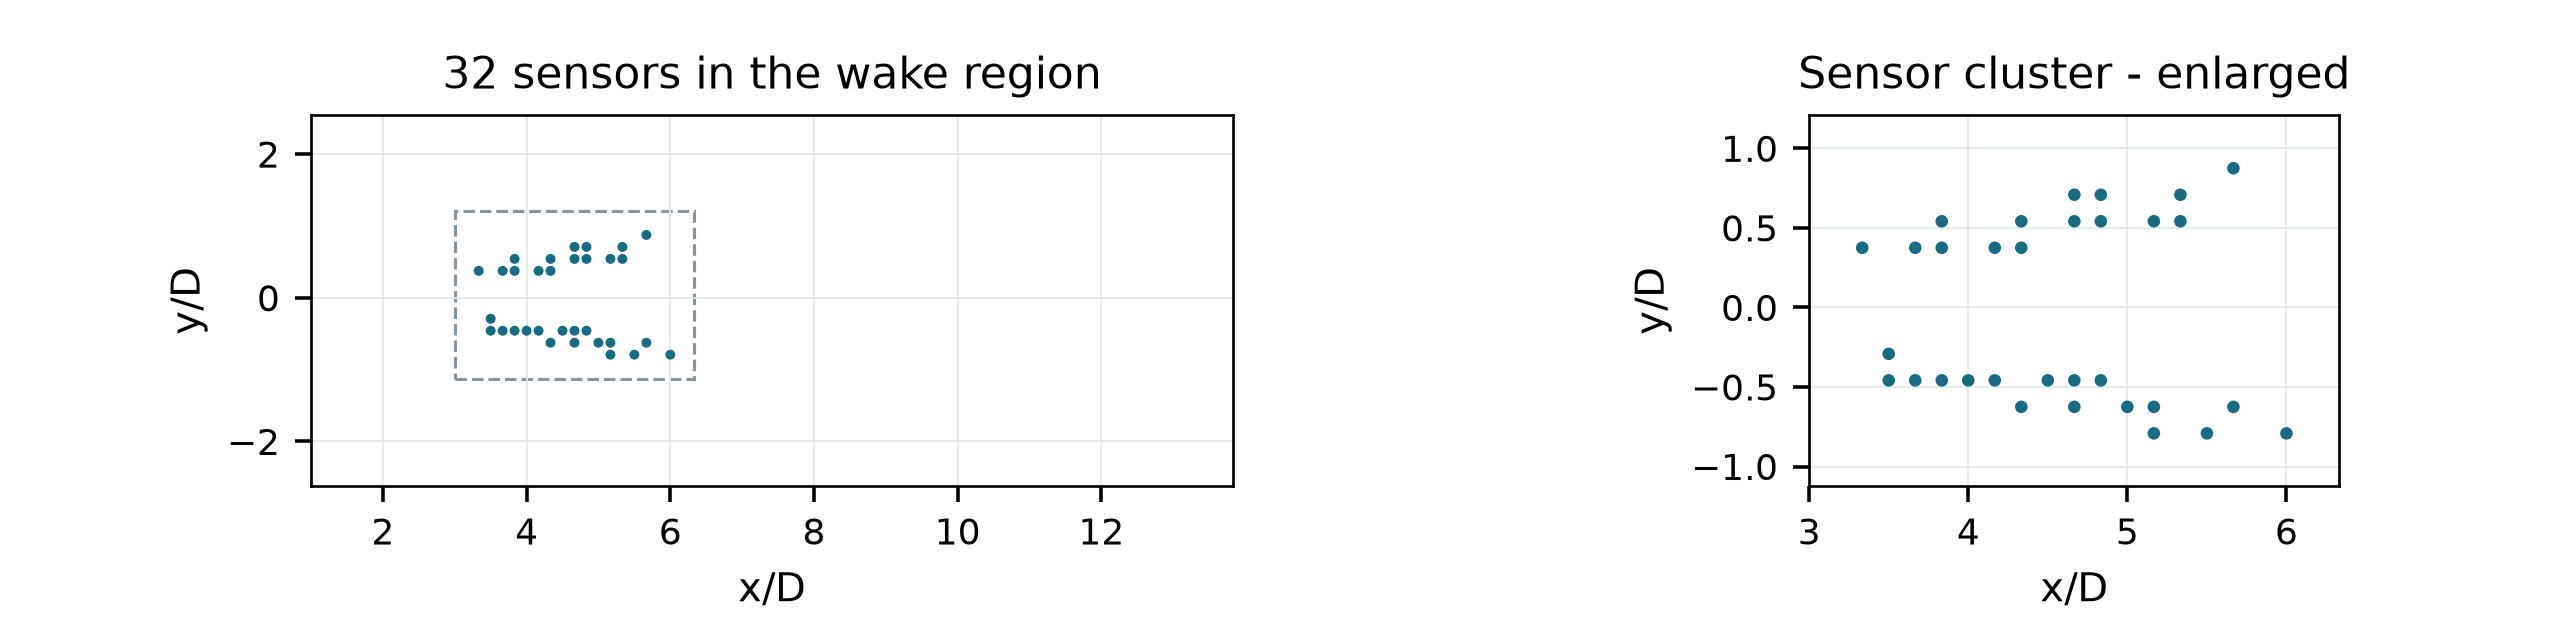

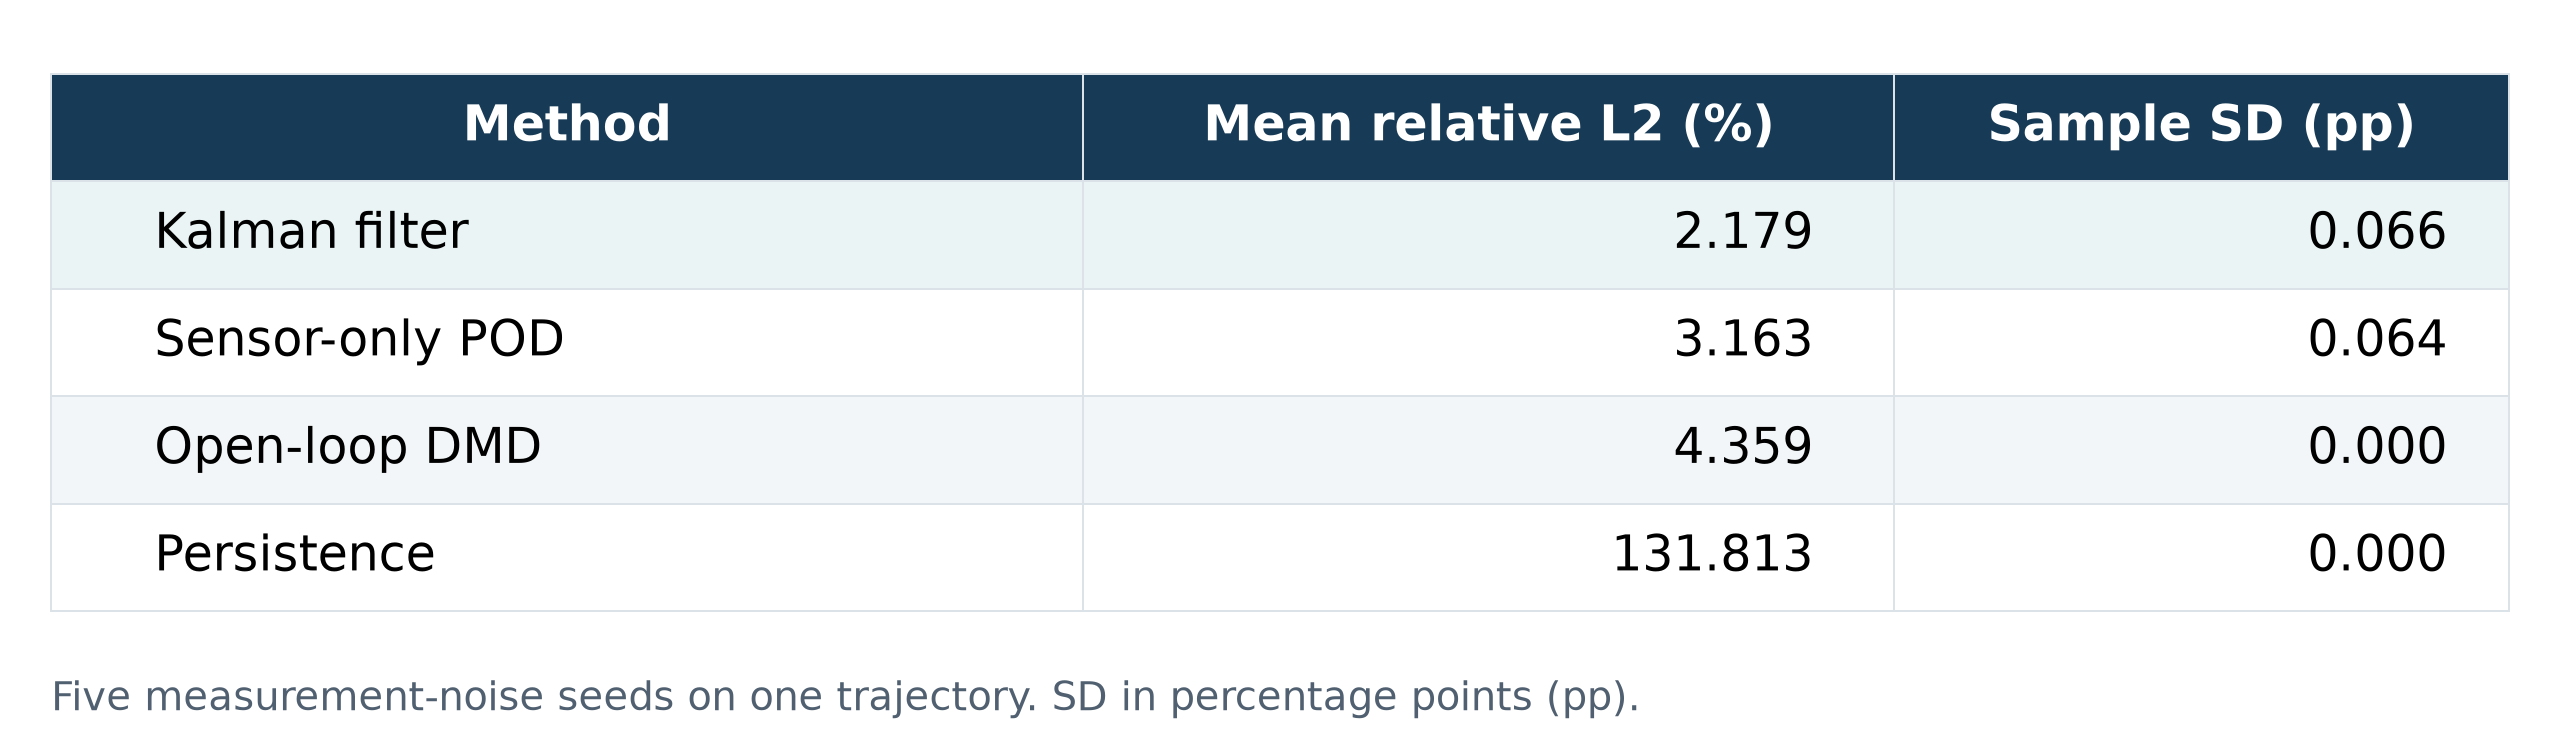

In [5]:
rows=[]
for name,records in result['methods'].items():
    values=100*np.array([r['test']['relative_l2'] for r in records])
    rows.append({'method':name,'test_relative_L2_mean_percent':values.mean(),
                 'sample_SD_percent':values.std(ddof=1)})
display(pd.DataFrame(rows).sort_values('test_relative_L2_mean_percent'))
display(Image(filename=str(scratch/'state_estimation_fields.png')))
display(Image(filename=str(scratch/'state_estimation_sensors.png')))
display(Image(filename=str(scratch/'state_estimation_scores.png')))

## 5. Audit uncertainty, not only the point estimate

Project the filtered modal covariance through the POD basis. The nominal 95%
marginal intervals cover only about 55% of test field values: a severe retained
under-coverage failure. They are not simultaneous spatial bands.

Explain how truncation, structural dynamics error, correlated field errors and
white-Gaussian assumptions can make accurate point estimates overconfident.
Propose validation-only calibration, then a genuinely untouched evaluation.

In [6]:
coverage=pd.DataFrame(result['coverage'])
display(coverage)
print('Mean nominal-95% pointwise coverage:',coverage.test_pointwise_95_coverage.mean())
assert coverage.test_pointwise_95_coverage.mean() < .75, 'Update the retained failure statement if behavior changes'

,seed,test_pointwise_95_coverage,mean_95_interval_width,normalized_innovation_rms
0,31,0.552315,0.007605,1.091143
1,32,0.529213,0.007605,1.076081
2,33,0.560604,0.007605,1.095285
3,34,0.575044,0.007605,1.078380
4,35,0.537790,0.007605,1.063800


Mean nominal-95% pointwise coverage: 0.550993138317082


## 6. Claim boundary and next experiment

The bounded conclusion is that current observations plus a reduced dynamical
prior improve this one retained trajectory under the declared artificial noise.
It is not evidence of new-Re generalization, pressure/force sensing, exact
continuum accuracy, or offline smoothing.

Next: predeclare missing-sensor bursts and a complete new-Re trajectory; select
all settings on development sequences. Reference: Särkkä and Svensson,
*Bayesian Filtering and Smoothing*, 2nd ed., 2023,
https://doi.org/10.1017/9781108917407. Code and figures here are independently
authored; no restricted handout material is incorporated.

In [7]:
after = {str(p): hashlib.sha256(p.read_bytes()).hexdigest() for p in tracked}
assert after == before, 'Notebook modified retained data/evidence'
print('PASS: retained data and evidence unchanged.')

PASS: retained data and evidence unchanged.
